> - 데이터셋 이름: Intelligent Manufacturing Dataset
> - 데이터 출처 URL: https://www.kaggle.com/datasets/ziya07/intelligent-manufacturing-dataset
> - 이 데이터를 선택한 이유: 관심이 있는 제조업 도메인에서의 데이터를 다뤄보고 싶어서
> - 각 행이 무엇을 의미하는지 (관측 단위): 특정 시점(Timestamp)에 특정 기계(Machine_ID)에서 수집된 1분 단위의 센서 측정 기록 1건
> - 주요 컬럼의 의미: 

| 컬럼 | 의미 | 
| --- | --- | 
| Timestamp | 측정 시각 (1분 단위) | 
| Machine_ID | 기계 식별자 (총 50대) |
| Operation_Mode | 측정 시점의 기계 작동 상태 (Idle/Active/Maintenance) |
| Temperature_C | 기계 온도 (섭씨) |
| Vibration_Hz | 진동 주파수 |
| Power_Consumption_kW | 전력 소비량 (kW) | 
| Network_Latency_ms | 기계-서버 간 통신 지연시간 (ms) |
| Packet_Loss_% | 네트워크 패킷 손실률 (%) |
| Quality_Control_Defect_Rate_% | 품질 검사 불량률 (%) |
| Production_Speed_units_per_hr | 시간당 생산 속도 |
| Predictive_Maintenance_Score | 예측 유지보수 점수 (낮을수록 정비 시급성 높음으로 추정) | 
| Error_Rate_% | 시스템/공정 오류율 (%) |
| Efficiency_Status | 종합 효율 등급 (Low/Medium/High, 다른 지표들을 종합해 산출된 것으로 추정) |
> - *실제 공장 데이터가 아닌 시뮬레이션 데이터*


In [1]:
import pandas as pd

mfg_raw = pd.read_csv("data/manufacturing_6G_dataset.csv")
print(mfg_raw.head())


             Timestamp  Machine_ID Operation_Mode  Temperature_C  \
0  2024-01-01 00:00:00          39           Idle      74.137590   
1  2024-01-01 00:01:00          29        Active       84.264558   
2  2024-01-01 00:02:00          15         Active      44.280102   
3  2024-01-01 00:03:00          43         active      40.568502   
4  2024-01-01 00:04:00           8           Idle      75.063817   

   Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  Packet_Loss_%  \
0      3.500595              8.612162           10.650542       0.207764   
1      3.355928              2.268559           29.111810       2.228464   
2      2.079766              6.144105           18.357292       1.639416   
3     -0.298238              4.067825           29.153629       1.161021   
4      0.345810              6.225737           34.029191       4.796520   

   Quality_Control_Defect_Rate_%  Production_Speed_units_per_hr  \
0                       7.751261                     477.657391   


In [2]:
# 1-1: 품질 진단
def quality_report_full(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base

qr_mfg = quality_report_full(mfg_raw, "mfg_raw")
qr_mfg

[품질 리포트(완전판)] mfg_raw
  행 수: 100,020  /  열 수: 13
  완전 중복 행: 20건
  📌 날짜로 보이는 object 컬럼: ['Timestamp']


C:\Users\ahnny\AppData\Local\Temp\ipykernel_28300\1349291390.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
C:\Users\ahnny\AppData\Local\Temp\ipykernel_28300\1349291390.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col], errors="coerce")
C:\Users\ahnny\AppData\Local\Temp\ipykernel_28300\1349291390.py:25: UserWarning: Could not infer format, s

,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime
Timestamp,str,0,0.0,100000,NaN,True
Machine_ID,int64,0,0.0,50,0.00,False
Operation_Mode,str,0,0.0,6,NaN,False
Temperature_C,float64,1000,1.0,99000,0.00,False
Vibration_Hz,float64,0,0.0,100000,0.54,False
Power_Consumption_kW,float64,0,0.0,98001,2.00,False
Network_Latency_ms,float64,0,0.0,100000,0.00,False
Packet_Loss_%,float64,0,0.0,100000,0.00,False
Quality_Control_Defect_Rate_%,float64,0,0.0,100000,0.00,False
Production_Speed_units_per_hr,float64,0,0.0,100000,0.00,False


In [3]:
# 1-2: 표기 혼재 상세 확인 (Operation_Mode)
print("=== Operation_Mode 고유값 ===")
print(mfg_raw["Operation_Mode"].unique())
print()

# 1-3: 이상치 상세 확인
print("=== Vibration_Hz 이상치 확인 ===")
print(mfg_raw["Vibration_Hz"].describe())
print()
print("=== Power_Consumption_kW 이상치 확인 ===")
print(mfg_raw["Power_Consumption_kW"].describe())

=== Operation_Mode 고유값 ===
<ArrowStringArray>
['Idle', ' Active ', 'Active', 'active', 'ACTIVE', 'Maintenance']
Length: 6, dtype: str

=== Vibration_Hz 이상치 확인 ===
count    100020.000000
mean          2.498379
std           1.503418
min          -4.995786
25%           1.285818
50%           2.524249
75%           3.764650
max           4.999974
Name: Vibration_Hz, dtype: float64

=== Power_Consumption_kW 이상치 확인 ===
count    100020.000000
mean          7.354245
std          11.519463
min           1.500183
25%           3.669817
50%           5.842327
75%           7.989758
max          86.188937
Name: Power_Consumption_kW, dtype: float64


c:\Users\ahnny\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ahnny\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ahnny\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ahnny\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ahnny\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) miss

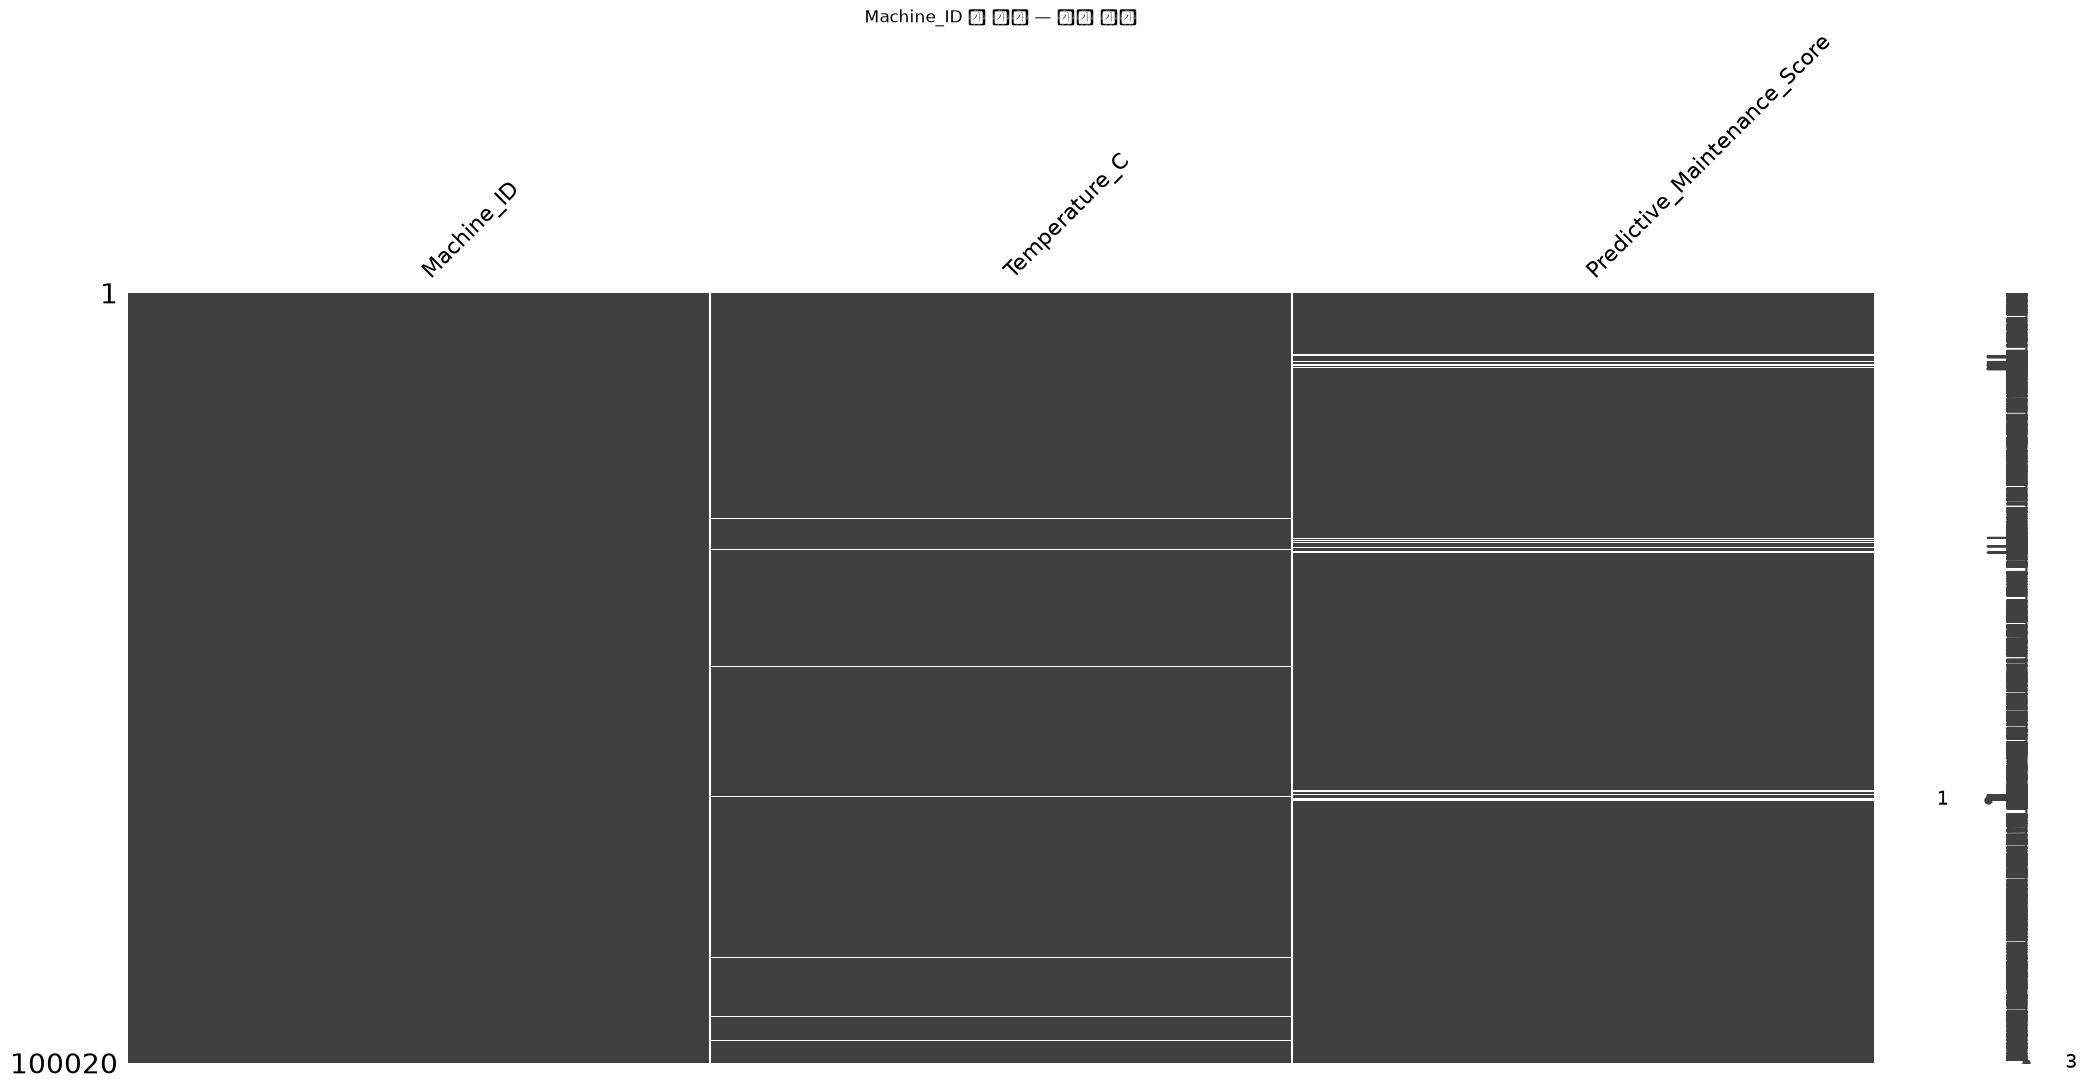

=== Temperature_C: Machine_ID별 결측 비율 (상위 5) ===
Machine_ID
12    1.432225
9     1.406328
41    1.390959
38    1.359883
30    1.350048
Name: Temperature_C, dtype: float64

=== Predictive_Maintenance_Score: Machine_ID별 결측 비율 (상위 5) ===
Machine_ID
5     30.709046
33    29.703476
17    28.675400
2      0.000000
4      0.000000
Name: Predictive_Maintenance_Score, dtype: float64


In [4]:
# 1-4: 결측치 상세 확인
import missingno as msno
import matplotlib.pyplot as plt

sorted_df = mfg_raw.sort_values("Machine_ID")
msno.matrix(sorted_df[["Machine_ID", "Temperature_C", "Predictive_Maintenance_Score"]])
plt.title("Machine_ID 순 정렬 — 결측 패턴")
plt.show()

def missing_pct_by_group(df, group_col, target_col):
    return (
        df.groupby(group_col)[target_col]
        .apply(lambda s: s.isna().mean() * 100)
        .sort_values(ascending=False)
    )

print("=== Temperature_C: Machine_ID별 결측 비율 (상위 5) ===")
print(missing_pct_by_group(mfg_raw, "Machine_ID", "Temperature_C").head())
print()

print("=== Predictive_Maintenance_Score: Machine_ID별 결측 비율 (상위 5) ===")
print(missing_pct_by_group(mfg_raw, "Machine_ID", "Predictive_Maintenance_Score").head())

In [ ]:
# 2: 정제 파이프라인
def drop_duplicates(df): 
    return df.drop_duplicates(keep="first").reset_index(drop=True)

def clean_operation_mode(df): 
    return df.assign(Operation_Mode=df["Operation_Mode"].str.strip().replace({"Active": "Active", "ACTIVE": "Active", "active": "Active"}))


def parse_date(df):
    return df.assign(Timestamp=pd.to_datetime(df["Timestamp"], format="mixed", errors="coerce"))


def remove_outliers(df):
    '''Vibration_Hz 음수 제거 + Power_Consumption_kW 상위 1% 컷오프'''
    q99 = df["Power_Consumption_kW"].quantile(0.99)
    cond = ((df["Vibration_Hz"] >= 0) & (df["Power_Consumption_kW"] < q99))
    return df[cond]


def drop_missing_temperature(df):
    '''Temperature_C 결측 행 제거'''
    return df.dropna(subset=["Temperature_C"]).reset_index(drop=True)


def impute_predictive_score(df):
    '''Predictive_Maintenance_Score 결측을 기계별 중앙값으로 대체하고, 결측 여부는 플래그로 보존'''
    df = df.copy()
    # 플래그: 결측이었다는 사실을 새 컬럼에 보존
    df["predictive_score_missing"] = df["Predictive_Maintenance_Score"].isnull().astype(int)
    # 기계별 중앙값으로 대체 
    df["Predictive_Maintenance_Score"] = df["Predictive_Maintenance_Score"].fillna(
        df.groupby("Machine_ID")["Predictive_Maintenance_Score"].transform("median")
    )
    return df

mfg_clean = (
    mfg_raw
    .pipe(drop_duplicates)
    .pipe(clean_operation_mode)
    .pipe(parse_date)
    .pipe(remove_outliers)
    .pipe(drop_missing_temperature)
    .pipe(impute_predictive_score)
)

print(f"정제 전: {mfg_raw.shape}  →  정제 후: {mfg_clean.shape}")
print(f"\nOperation_Mode 종류: {mfg_clean['Operation_Mode'].unique()}")
print(f"\nTimestamp dtype: {mfg_clean['Timestamp'].dtype}")
print(f"Timestamp 파싱 실패(NaT) 개수: {mfg_clean['Timestamp'].isna().sum()}")
print("\n처리 후 결측:")
print(mfg_clean.isnull().sum())

정제 전: (100020, 13)  →  정제 후: (96049, 14)

Operation_Mode 종류: <ArrowStringArray>
['Idle', 'Active', 'Maintenance']
Length: 3, dtype: str

Timestamp dtype: datetime64[us]
Timestamp 파싱 실패(NaT) 개수: 0

처리 후 결측:
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
predictive_score_missing         0
dtype: int64


In [6]:
# 결정 로그: 실제 데이터에서 값 계산

n_dup = mfg_raw.duplicated().sum()

n_before_str = mfg_raw["Operation_Mode"].nunique()
n_after_str = mfg_clean["Operation_Mode"].nunique()

n_date_fail = mfg_clean["Timestamp"].isna().sum()

n_vibration_removed = (mfg_raw["Vibration_Hz"] < 0).sum()
q99 = mfg_raw["Power_Consumption_kW"].quantile(0.99)
n_power_removed = (mfg_raw["Power_Consumption_kW"] >= q99).sum()

n_temp_removed = mfg_raw["Temperature_C"].isna().sum()
n_score_imputed = mfg_clean["predictive_score_missing"].sum()

decisions = [
    {
        "step": "중복 제거",
        "action": "완전 중복 행 drop",
        "reason": "동일 키·동일 값이 반복되는 것은 시스템 중복 입력 오류로 간주",
        "result": f"{n_dup}건 제거",
    },
    {
        "step": "문자열 정제",
        "action": "Operation_Mode를 strip 후 'Active'로 표기 통일",
        "reason": "' Active ', 'active', 'Active', 'ACTIVE'는 동일한 작동 모드",
        "result": f"작동모드 표기 {n_before_str}종 → {n_after_str}종으로 통일",
    },
    {
        "step": "날짜 파싱",
        "action": "Timestamp를 문자열에서 datetime으로 변환",
        "reason": "원본에 날짜 포맷이 섞여 있어 문자열 상태로는 시계열 집계·정렬 불가",
        "result": f"파싱 실패(NaT) {n_date_fail}건",
    },
    {
        "step": "이상치 처리",
        "action": "Vibration_Hz 음수 제거, Power_Consumption_kW 상위 1% 컷오프",
        "reason": "진동은 물리적으로 음수가 될 수 없는 값이며, 전력소비 극단값은 센서 오류로 추정",
        "result": f"Vibration_Hz 음수 {n_vibration_removed}건, Power 상위 1% {n_power_removed}건 제거",
    },
    {
        "step": "결측치 처리",
        "action": "Temperature_C 결측 행 제거, Predictive_Maintenance_Score는 Machine_ID별 중앙값으로 대체 후 플래그 보존",
        "reason": "온도 결측은 기계 간 비율 차이가 거의 없어 MCAR로 판단해 제거. Predictive_Maintenance_Score는 특정 기계(5,17,33)에 몰려있어 MAR로 판단해 그룹별 대체로 정보 손실 최소화",
        "result": f"Temperature_C {n_temp_removed}건 제거, Predictive_Maintenance_Score {n_score_imputed}건 대체",
    },
]

from IPython.display import Markdown, display

md_table = "| 단계 | 액션 | 근거 | 결과 |\n|---|---|---|---|\n"
for d in decisions:
    md_table += f"| {d['step']} | {d['action']} | {d['reason']} | {d['result']} |\n"

display(Markdown(md_table))  

| 단계 | 액션 | 근거 | 결과 |
|---|---|---|---|
| 중복 제거 | 완전 중복 행 drop | 동일 키·동일 값이 반복되는 것은 시스템 중복 입력 오류로 간주 | 20건 제거 |
| 문자열 정제 | Operation_Mode를 strip 후 'Active'로 표기 통일 | ' Active ', 'active', 'Active', 'ACTIVE'는 동일한 작동 모드 | 작동모드 표기 6종 → 3종으로 통일 |
| 날짜 파싱 | Timestamp를 문자열에서 datetime으로 변환 | 원본에 날짜 포맷이 섞여 있어 문자열 상태로는 시계열 집계·정렬 불가 | 파싱 실패(NaT) 0건 |
| 이상치 처리 | Vibration_Hz 음수 제거, Power_Consumption_kW 상위 1% 컷오프 | 진동은 물리적으로 음수가 될 수 없는 값이며, 전력소비 극단값은 센서 오류로 추정 | Vibration_Hz 음수 1000건, Power 상위 1% 2000건 제거 |
| 결측치 처리 | Temperature_C 결측 행 제거, Predictive_Maintenance_Score는 Machine_ID별 중앙값으로 대체 후 플래그 보존 | 온도 결측은 기계 간 비율 차이가 거의 없어 MCAR로 판단해 제거. Predictive_Maintenance_Score는 특정 기계(5,17,33)에 몰려있어 MAR로 판단해 그룹별 대체로 정보 손실 최소화 | Temperature_C 1000건 제거, Predictive_Maintenance_Score 1730건 대체 |


In [8]:
# 3: 변환 + 저장 
# KPI 1: 효율 등급별 평균 생산 속도·오류율·불량율
eff_kpi = (
    mfg_clean.groupby("Efficiency_Status")
    .agg(
        avg_speed=("Production_Speed_units_per_hr", "mean"),
        avg_error_rate=("Error_Rate_%", "mean"),
        avg_defect=("Quality_Control_Defect_Rate_%", "mean"),
        n_records=("Efficiency_Status", "count"),
    )
    .round(2)
    .sort_values("avg_speed", ascending=False)
)
print("효율 등급별 KPI:")
display(eff_kpi)

# KPI 2: 기계별 효율 등급 분포
machine_eff = (
    mfg_clean.groupby(["Machine_ID", "Efficiency_Status"]).size().unstack(fill_value=0)
)
machine_eff = machine_eff[["High", "Medium", "Low"]]
print("기계별 효율 등급 분포:")
display(machine_eff)

# Parquet 저장
from pathlib import Path
OUT_DIR = Path("./outputs")
eff_kpi.to_parquet(OUT_DIR / "manufacturing_efficiency_kpi.parquet")
machine_eff.to_parquet(OUT_DIR / "manufacturing_machine_efficiency.parquet")
print(f"\nParquet 저장 완료: {OUT_DIR.resolve()}")

효율 등급별 KPI:


,avg_speed,avg_error_rate,avg_defect,n_records
Efficiency_Status,,,,
High,450.84,1.01,4.91,2871
Medium,334.33,2.73,4.98,18394
Low,254.90,8.93,5.02,74784


기계별 효율 등급 분포:


Efficiency_Status,High,Medium,Low
Machine_ID,,,
1,54,377,1415
2,56,372,1550
3,55,362,1511
4,50,360,1504
5,71,361,1521
6,57,365,1436
7,59,370,1461
8,51,318,1524
9,51,338,1518



Parquet 저장 완료: C:\Users\ahnny\ai-data-bootcamp\D009\outputs
